In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")  
    print("Found GPU")
else:
    torch.device("cpu")
    
print("Pytorch version:", torch.__version__)

Found GPU
Pytorch version: 2.4.1+cu121


## Login to Wandb to log experiment

In [3]:
os.environ['WANDB_NOTEBOOK_NAME'] = 'EuroSat_ResNet_Classifier.ipynb'



In [4]:
# NEW (your local Windows path)
data_path = r"C:\Users\Ekagr\Desktop\eurosat_classification\train_eval_code\dataset_rgb\\"


In [5]:
# Load the labels 
f = open(f"{data_path}label_map.json", "r")
label_to_index = json.load(f)

In [6]:
index_to_label = {label_to_index[k]:k for k in label_to_index}
print(index_to_label)

{0: 'AnnualCrop', 1: 'Forest', 2: 'HerbaceousVegetation', 3: 'Highway', 4: 'Industrial', 5: 'Pasture', 6: 'PermanentCrop', 7: 'Residential', 8: 'River', 9: 'SeaLake'}


## Data Transformations

In [7]:
# Define a sequence of transformations to be applied to images
transformToTensor = transforms.Compose([
    # Resize the image to have a minimum size of 64 pixels along the shortest dimension,
    # preserving the aspect ratio of the original image.
    transforms.Resize((64,)),

    # Crop the image at the center to get a 64x64 square.
    transforms.CenterCrop((64, 64)),

    # Convert the image to a PyTorch tensor.
    transforms.ToTensor(),

    # Normalize the tensor image with mean and standard deviation for each color channel.
    # These specific values are generally used for pre-trained models.
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Create dataset instances
# Instantiate the EurosatDataset class for training data.
train_dataset = EurosatDataset(_type='train', transform=transformToTensor,
                               data_path=data_path)

# Instantiate the EurosatDataset class for validation data.
valid_dataset = EurosatDataset(_type="valid", transform=transformToTensor,
                               data_path=data_path)

# Instantiate the EurosatDataset class for testing data.
test_dataset = EurosatDataset(_type="test", transform=transformToTensor,
                              data_path=data_path)

# Define batch sizes for training and validation data.
train_batch = 64  # The batch size for training data.
val_batch = 16     # The batch size for validation data.


train_loader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True)


valid_loader = DataLoader(valid_dataset, batch_size=val_batch, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

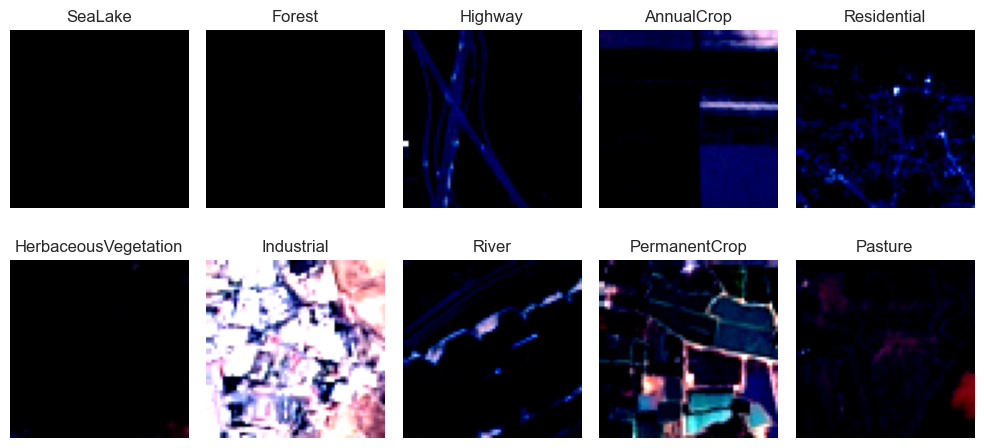

In [9]:
visualize_classes(train_loader, index_to_label)

In [10]:
dataset_managers = {
    'valid': valid_loader,
    'train': train_loader,
    'test': test_loader
}

print(f"Train set batches: {len(train_loader)}")
print(f"Validation set batches: {len(valid_loader)}")
print(f"Test set examples: {len(test_loader)}")

Train set batches: 296
Validation set batches: 338
Test set examples: 2700


## Labels distribution

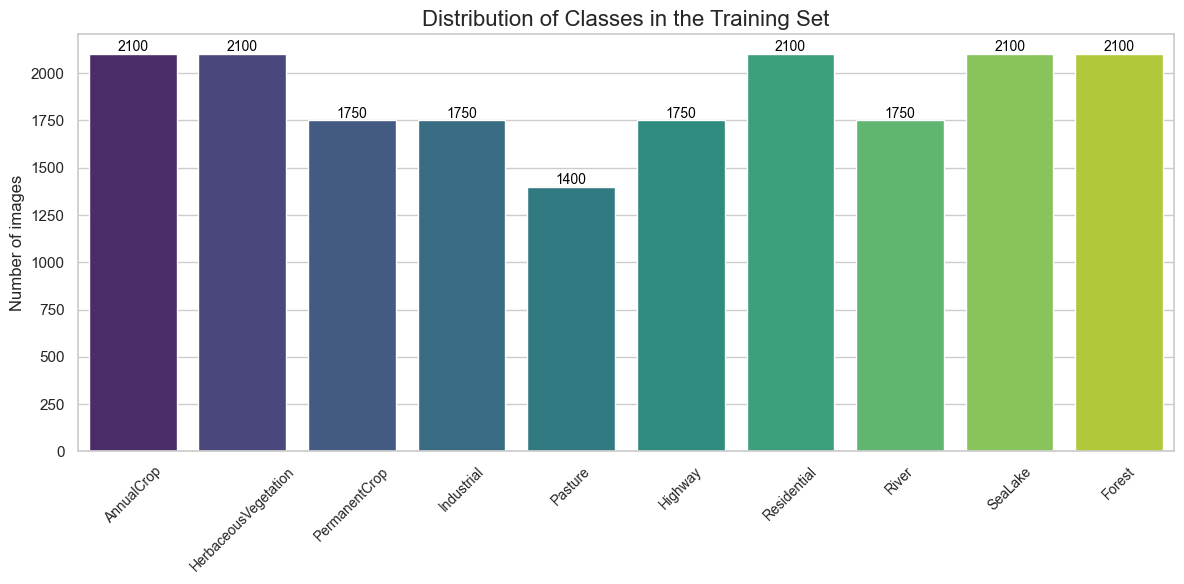

In [11]:
labels = train_dataset.data['Label'].values  # Assuming 'Label' is the column with labels

# Convert numerical labels to string names if necessary
label_names = [index_to_label[label] for label in labels]

sns.set(style="whitegrid")  # Set style
plt.figure(figsize=(12, 6))

# Adjusted according to the new API
ax = sns.countplot(x=label_names, hue=label_names, palette="viridis", legend=False)

#plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of images', fontsize=12)
plt.title('Distribution of Classes in the Training Set', fontsize=16)
plt.xticks(rotation=45, fontsize=10)

# Add the count above the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()



# Model

In [12]:
# Use un-pretrained model
model = resnet50()

# Replace the model head with the number of classes
num_classes = 10
model.fc = nn.Linear(2048, num_classes) 
model.to(DEVICE)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# Training model from Scratch

In [13]:
project_name = "EuroSAT"
model_name = "ResNet50"
models_path = "/datasets2/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models"

In [16]:
epochs = 200
lr = 0.0001
patience = 10

print("Training started...")

loss_i, loss_val_i = train_model(model=model, epochs=epochs, 
                                 train_loader=train_loader,
                                 valid_loader=valid_loader,
                                 lr=lr, patience=patience, device=DEVICE)

Training started...
Starting training with early stopping patience of 10
Each epoch has 296 steps.

Epoch: 1...
Step: 21/296 | Train Loss: 2.1253
Step: 41/296 | Train Loss: 1.7220
Step: 61/296 | Train Loss: 1.6441
Step: 81/296 | Train Loss: 1.4721
Step: 101/296 | Train Loss: 1.3707
Step: 121/296 | Train Loss: 1.3017
Step: 141/296 | Train Loss: 1.1839
Step: 161/296 | Train Loss: 1.1447
Step: 181/296 | Train Loss: 1.1417
Step: 201/296 | Train Loss: 1.0788
Step: 221/296 | Train Loss: 1.1014
Step: 241/296 | Train Loss: 1.1464
Step: 261/296 | Train Loss: 1.0569
Step: 281/296 | Train Loss: 1.0401
Val Loss: 0.9650 | Val Accuracy: 0.6439 (64.39%)
Best model saved.
Epoch duration: 106.03s

Epoch: 2...
Step: 21/296 | Train Loss: 1.1248
Step: 41/296 | Train Loss: 1.2468
Step: 61/296 | Train Loss: 1.0446
Step: 81/296 | Train Loss: 0.9815
Step: 101/296 | Train Loss: 0.9782
Step: 121/296 | Train Loss: 0.9105
Step: 141/296 | Train Loss: 0.8314
Step: 161/296 | Train Loss: 0.8951
Step: 181/296 | Train 

## Save model

In [17]:
# Create models directory
os.makedirs(models_path, exist_ok=True)

# 2. Create model save path
model_save_path = os.path.join(models_path, model_name + ".pth")

# 3. Save the model state dict
print(f"Saving model to: {model_save_path}")
torch.save(obj=model.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=model_save_path)

Saving model to: /datasets2/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models\ResNet50.pth


In [18]:
# Save the loss data in a file
with open(f"{models_path}/loss_{model_name}.txt", "w") as file:
    file.write(f"loss_i: {loss_i}\n")
    file.write(f"loss_val_i: {loss_val_i}\n")

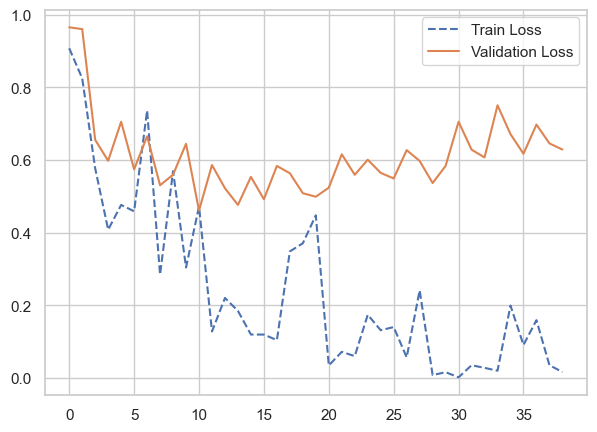

In [19]:
plt.figure(figsize=(7,5))
# Use a dashed line for the training loss, and add markers
plt.plot(loss_i, label="Train Loss", linestyle='--', alpha=1.0)

# Use a solid line for the validation loss
plt.plot(loss_val_i, label="Validation Loss", linestyle='-', alpha=1.0)
plt.legend()
plt.show()

# Evaluate model

## Load trained model

In [21]:
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
model_save_path = models_path + "/" + model_name + ".pth"
print(f"Loading {model_save_path}")
model.load_state_dict(torch.load(f = model_save_path))

Loading /datasets2/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models/ResNet50.pth


C:\Users\Ekagr\AppData\Local\Temp\ipykernel_58136\397842506.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f = model_save_path))


<All keys matched successfully>

In [22]:
evaluate_test_set(model, test_loader, DEVICE, index_to_label=index_to_label)

                      precision    recall  f1-score   support

          AnnualCrop      0.926     0.840     0.881       300
              Forest      0.937     0.990     0.963       300
HerbaceousVegetation      0.798     0.777     0.787       300
             Highway      0.748     0.688     0.717       250
          Industrial      0.940     0.936     0.938       250
             Pasture      0.823     0.815     0.819       200
       PermanentCrop      0.672     0.796     0.729       250
         Residential      0.967     0.967     0.967       300
               River      0.779     0.760     0.769       250
             SeaLake      0.977     0.983     0.980       300

            accuracy                          0.861      2700
           macro avg      0.857     0.855     0.855      2700
        weighted avg      0.863     0.861     0.861      2700



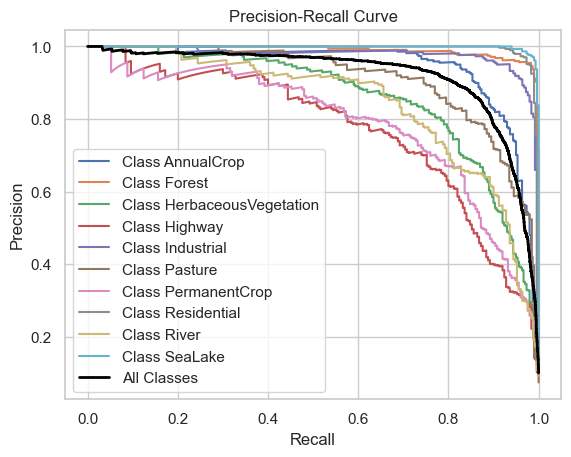

In [23]:
precision_recall_analysis(model, test_loader, DEVICE,
                          output_path=models_path,
                          model_name=model_name,
                          index_to_label=index_to_label)

## Load the precision/recall curve and plot it

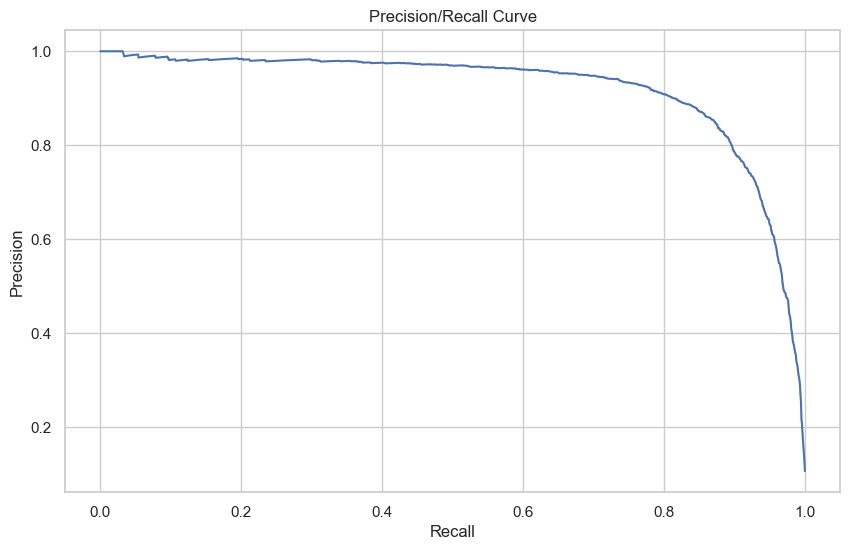

In [24]:
filename = f"{model_name}_precision_recall_values.json"
file_path = os.path.join(models_path, filename)

with open(file_path, 'r') as file:
    precision_recall_data = json.load(file)
    
all_classes_data = precision_recall_data['All Classes']

# Extract precision and recall values
precisions = all_classes_data.get('precision', [])
recalls = all_classes_data.get('recall', [])

# Create a DataFrame for plotting
df = pd.DataFrame({
    'Precision': precisions,
    'Recall': recalls
})

# Plotting the precision/recall curve
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Recall', y='Precision')
plt.title('Precision/Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

## Clean-up

In [15]:
import gc

del model
torch.cuda.empty_cache()
gc.collect()


26125

# Now train the model with pre-trained weights

In [25]:
# Use pretrained model
model2=resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# Replace the model head with the number of classes
num_classes = 10
model2.fc = nn.Linear(2048, num_classes) 
model2.to(DEVICE)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Train

In [26]:
model_name = "ResNet50-Pretrained"

In [27]:
epochs = 200
lr = 0.0001
patience = 10

print("Training started...")

loss_i, loss_val_i = train_model(model=model2, epochs=epochs, 
                                 train_loader=train_loader,
                                 valid_loader=valid_loader,
                                 lr=lr, patience=patience, device=DEVICE)

Training started...
Starting training with early stopping patience of 10
Each epoch has 296 steps.

Epoch: 1...
Step: 21/296 | Train Loss: 1.4213
Step: 41/296 | Train Loss: 0.4605
Step: 61/296 | Train Loss: 0.2953
Step: 81/296 | Train Loss: 0.2139
Step: 101/296 | Train Loss: 0.2375
Step: 121/296 | Train Loss: 0.1980
Step: 141/296 | Train Loss: 0.1722
Step: 161/296 | Train Loss: 0.2152
Step: 181/296 | Train Loss: 0.1682
Step: 201/296 | Train Loss: 0.1646
Step: 221/296 | Train Loss: 0.1501
Step: 241/296 | Train Loss: 0.1688
Step: 261/296 | Train Loss: 0.1466
Step: 281/296 | Train Loss: 0.1791
Val Loss: 0.1075 | Val Accuracy: 0.9652 (96.52%)
Best model saved.
Epoch duration: 114.10s

Epoch: 2...
Step: 21/296 | Train Loss: 0.1275
Step: 41/296 | Train Loss: 0.2348
Step: 61/296 | Train Loss: 0.2575
Step: 81/296 | Train Loss: 0.2374
Step: 101/296 | Train Loss: 0.1390
Step: 121/296 | Train Loss: 0.1907
Step: 141/296 | Train Loss: 0.1580
Step: 161/296 | Train Loss: 0.1696
Step: 181/296 | Train 

## Save model

In [28]:
# Create models directory
os.makedirs(models_path, exist_ok=True)

# 2. Create model save path
model_save_path = os.path.join(models_path, model_name + ".pth")

# 3. Save the model state dict
print(f"Saving model to: {model_save_path}")
torch.save(obj=model2.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=model_save_path)

Saving model to: /datasets2/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models\ResNet50-Pretrained.pth


In [29]:
# Save the loss data in a file
with open(f"{models_path}/loss_{model_name}.txt", "w") as archivo:
    archivo.write(f"loss_i: {loss_i}\n")
    archivo.write(f"loss_val_i: {loss_val_i}\n")

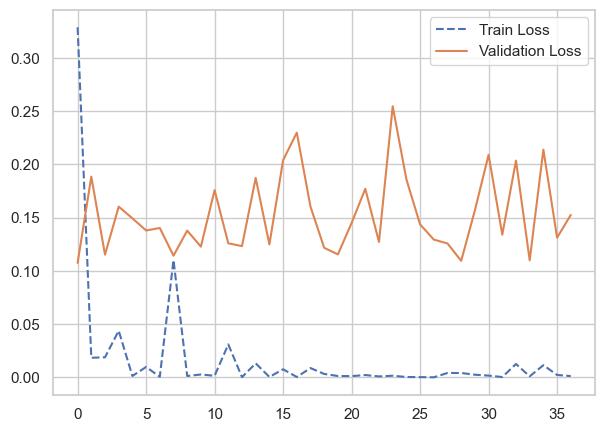

In [30]:
plt.figure(figsize=(7,5))
# Use a dashed line for the training loss, and add markers
plt.plot(loss_i, label="Train Loss", linestyle='--', alpha=1.0)

# Use a solid line for the validation loss
plt.plot(loss_val_i, label="Validation Loss", linestyle='-', alpha=1.0)
plt.legend()
plt.show()

# Evaluate model

## Load trained model

In [32]:
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
model_save_path = models_path + "/" + model_name + ".pth"
print(f"Loading {model_save_path}")
model2.load_state_dict(torch.load(f = model_save_path))

Loading /datasets2/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models/ResNet50-Pretrained.pth


C:\Users\Ekagr\AppData\Local\Temp\ipykernel_58136\3005568182.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model2.load_state_dict(torch.load(f = model_save_path))


<All keys matched successfully>

In [33]:
evaluate_test_set(model2, test_loader, DEVICE, index_to_label=index_to_label)

                      precision    recall  f1-score   support

          AnnualCrop      0.937     0.993     0.964       300
              Forest      0.990     0.993     0.992       300
HerbaceousVegetation      0.921     0.970     0.945       300
             Highway      0.976     0.992     0.984       250
          Industrial      0.984     0.988     0.986       250
             Pasture      0.990     0.960     0.975       200
       PermanentCrop      0.977     0.844     0.906       250
         Residential      0.993     0.993     0.993       300
               River      0.984     0.980     0.982       250
             SeaLake      0.997     1.000     0.998       300

            accuracy                          0.973      2700
           macro avg      0.975     0.971     0.972      2700
        weighted avg      0.974     0.973     0.973      2700



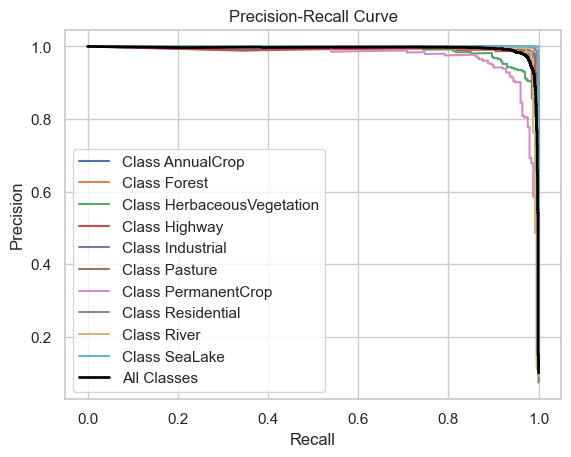

In [34]:
precision_recall_analysis(model2, test_loader, DEVICE,
                          output_path=models_path,
                          model_name=model_name,
                          index_to_label=index_to_label)

In [23]:
del model2
torch.cuda.empty_cache()
gc.collect()

821